# VIX Distribution Properties

This notebook studies the descriptive distribution of daily VIX Close and monthly VIX High. It compares raw and log-transformed values, checks Q-Q behavior, and examines stability across market regimes.

Strategy-specific thresholds and wave rules are documented in the [VIX event strategy](../04_vix_event_strategy/README.md).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import kurtosis, shapiro, skew


def distribution_stats(series, name):
    clean = series.dropna()
    sample = clean.sample(5000, random_state=42) if len(clean) > 5000 else clean
    shapiro_stat, shapiro_p = shapiro(sample)
    return pd.Series({
        "Name": name,
        "Count": len(clean),
        "Mean": clean.mean(),
        "Std": clean.std(),
        "Median": clean.median(),
        "Min": clean.min(),
        "Max": clean.max(),
        "Skewness": skew(clean),
        "Kurtosis_Excess": kurtosis(clean),
        "Shapiro_Stat": shapiro_stat,
        "Shapiro_p": shapiro_p,
    })


## Data preparation

Daily Close represents the commonly observed VIX level. Monthly High captures the upper stress level reached within each month; here it is a distribution variable, not an event signal.


In [2]:
DATA_URL = "https://raw.githubusercontent.com/datasets/finance-vix/master/data/vix-daily.csv"

vix = (
    pd.read_csv(DATA_URL, parse_dates=["DATE"])
    .rename(columns={"DATE": "Date"})
    .set_index("Date")
    .sort_index()
)

daily_close = vix["CLOSE"].rename("VIX_Close").dropna()
monthly_high = vix["HIGH"].resample("ME").max().rename("VIX_High").dropna()

distribution_data = pd.DataFrame({
    "Daily_Close": daily_close,
    "Log_Daily_Close": np.log(daily_close),
})

monthly_data = pd.DataFrame({
    "Monthly_High": monthly_high,
    "Log_Monthly_High": np.log(monthly_high),
})

print(f"Daily sample: {daily_close.index.min().date()} to {daily_close.index.max().date()}")
print(f"Monthly sample: {monthly_high.index.min().date()} to {monthly_high.index.max().date()}")


Daily sample: 1990-01-02 to 2026-07-24
Monthly sample: 1990-01-31 to 2026-07-31


## Raw and log distribution comparison


In [3]:
summary = pd.DataFrame([
    distribution_stats(distribution_data["Daily_Close"], "Raw daily VIX Close"),
    distribution_stats(distribution_data["Log_Daily_Close"], "Log daily VIX Close"),
    distribution_stats(monthly_data["Monthly_High"], "Raw monthly VIX High"),
    distribution_stats(monthly_data["Log_Monthly_High"], "Log monthly VIX High"),
])

display(summary)


,Name,Count,Mean,Std,Median,Min,Max,Skewness,Kurtosis_Excess,Shapiro_Stat,Shapiro_p
0,Raw daily VIX Close,9236,19.442309,7.731125,17.610000,9.140000,82.690000,2.212488,8.763305,0.828196,9.420072e-59
1,Log daily VIX Close,9236,2.904906,0.340117,2.868467,2.212660,4.415099,0.670149,0.522693,0.968936,1.431726e-31
2,Raw monthly VIX High,439,25.015763,10.690623,22.440000,12.440000,89.530000,2.171059,7.477106,0.823104,1.214116e-21
3,Log monthly VIX High,439,3.148452,0.361709,3.110845,2.520917,4.494574,0.693882,0.474597,0.966845,2.084068e-08


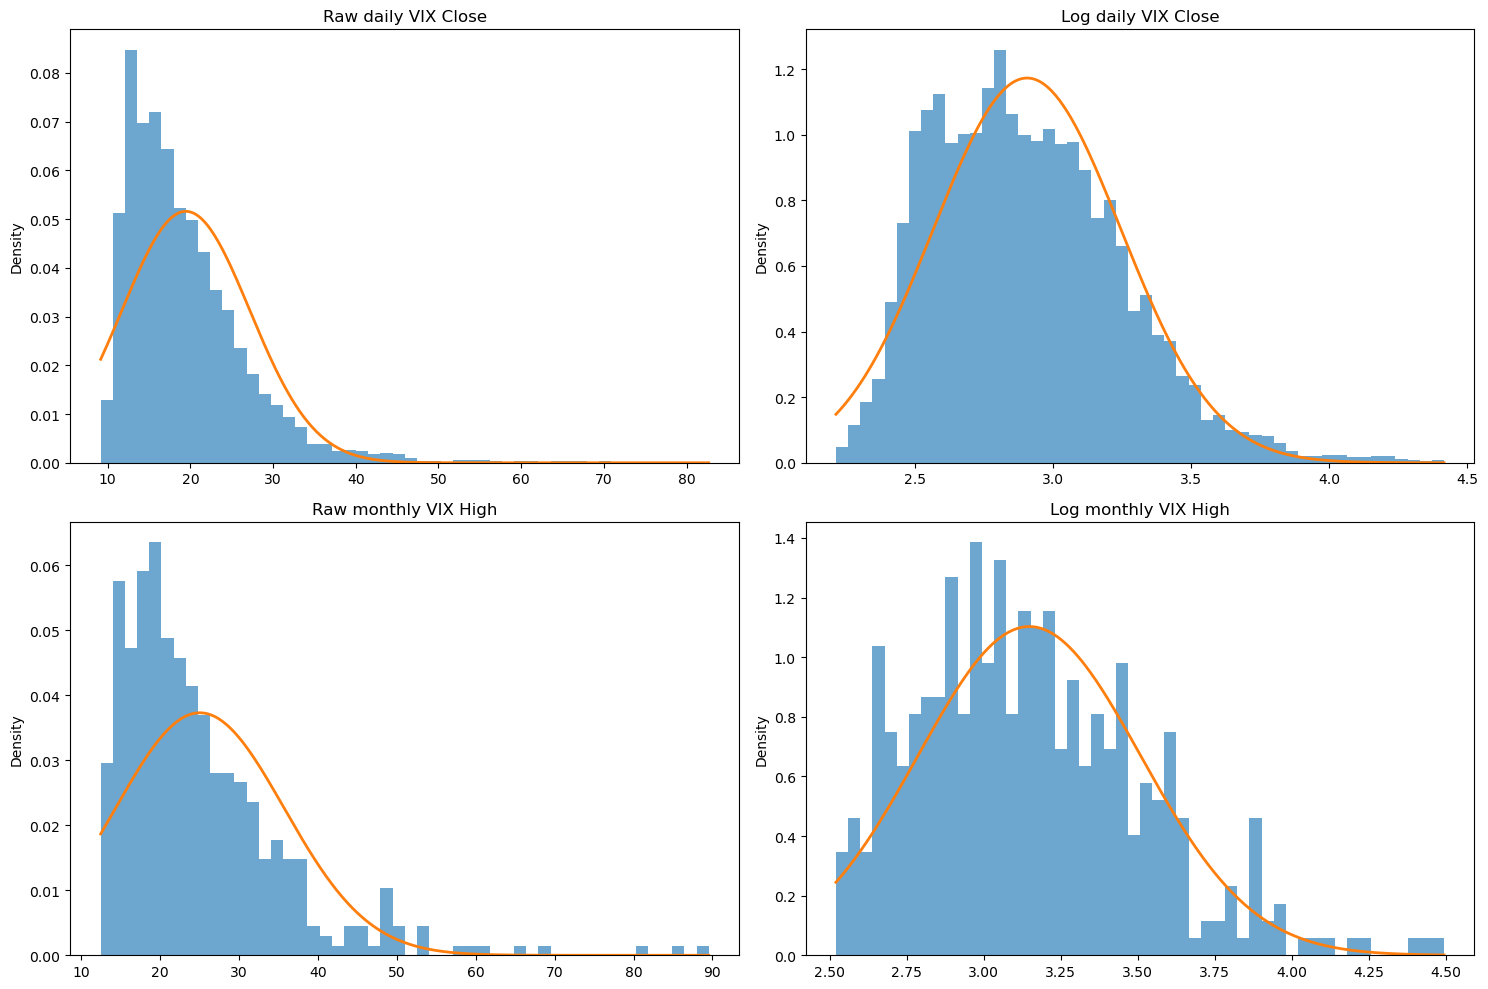

In [4]:
series_to_plot = [
    (distribution_data["Daily_Close"], "Raw daily VIX Close"),
    (distribution_data["Log_Daily_Close"], "Log daily VIX Close"),
    (monthly_data["Monthly_High"], "Raw monthly VIX High"),
    (monthly_data["Log_Monthly_High"], "Log monthly VIX High"),
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for axis, (series, title) in zip(axes.flat, series_to_plot):
    clean = series.dropna()
    axis.hist(clean, bins=50, density=True, alpha=0.65)
    x = np.linspace(clean.min(), clean.max(), 300)
    axis.plot(x, stats.norm.pdf(x, clean.mean(), clean.std()), linewidth=2)
    axis.set_title(title)
    axis.set_ylabel("Density")

plt.tight_layout()
plt.show()


## Q-Q plots

The plots test the shape of the center and tails rather than assuming a perfect normal or lognormal model.


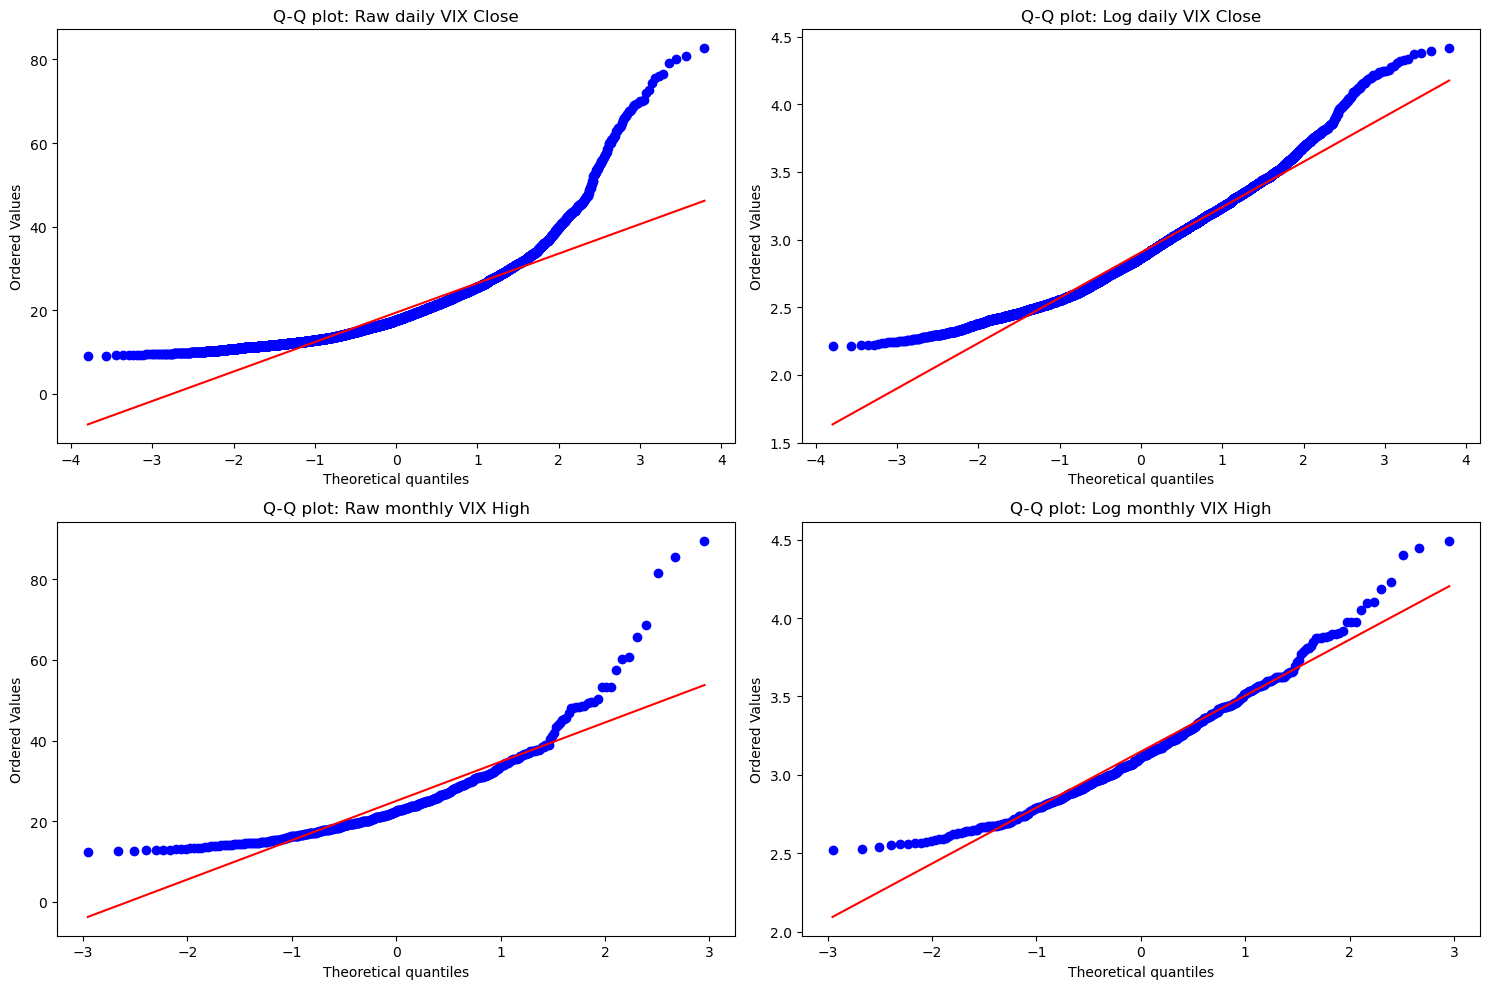

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for axis, (series, title) in zip(axes.flat, series_to_plot):
    stats.probplot(series.dropna(), dist="norm", plot=axis)
    axis.set_title(f"Q-Q plot: {title}")

plt.tight_layout()
plt.show()


## Regime comparison of monthly VIX High


,Name,Count,Mean,Std,Median,Min,Max,Skewness,Kurtosis_Excess,Shapiro_Stat,Shapiro_p
0,1995-2007,156,3.143806,0.342983,3.151564,2.520917,3.902579,0.096637,-0.674010,0.977885,0.013088
1,2008-2019,144,3.149618,0.392460,3.062688,2.556452,4.494574,0.993809,0.813062,0.932795,0.000002
2,2020-present,79,3.292732,0.355246,3.243373,2.660959,4.448165,0.729415,0.643166,0.962648,0.020731


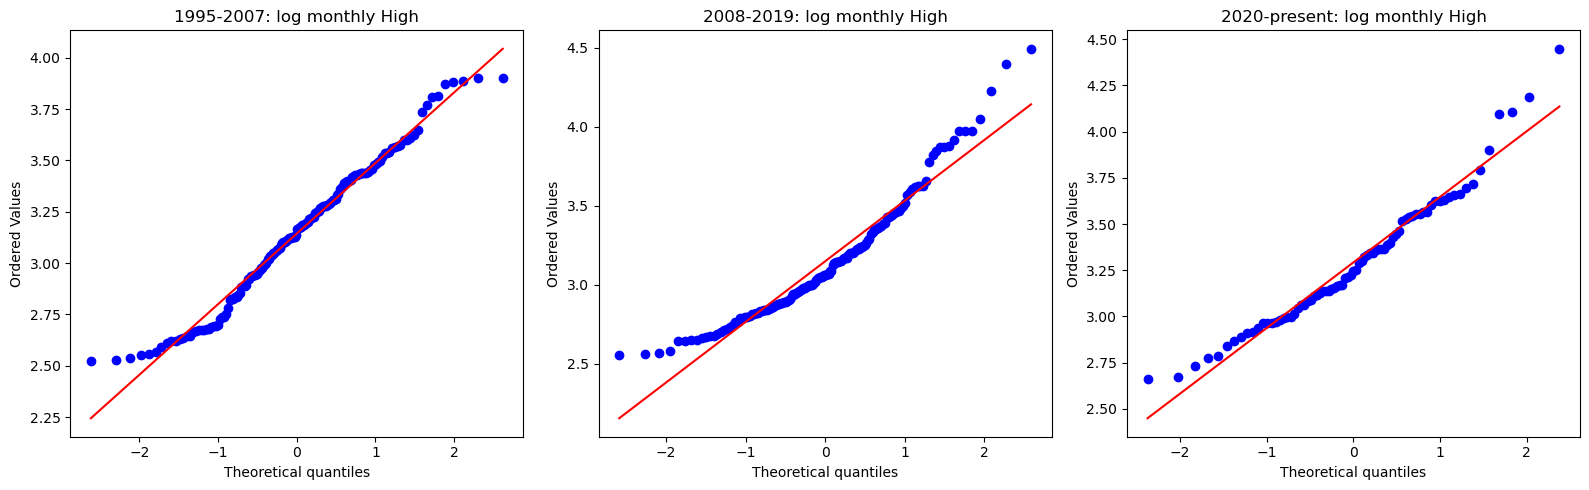

In [6]:
periods = {
    "1995-2007": ("1995-01-01", "2007-12-31"),
    "2008-2019": ("2008-01-01", "2019-12-31"),
    "2020-present": ("2020-01-01", None),
}

regime_rows = []
for name, (start, end) in periods.items():
    subset = monthly_data.loc[start:end, "Log_Monthly_High"]
    if len(subset) >= 10:
        regime_rows.append(distribution_stats(subset, name))

regime_summary = pd.DataFrame(regime_rows)
display(regime_summary)

fig, axes = plt.subplots(1, len(regime_rows), figsize=(16, 5))
for axis, row in zip(np.atleast_1d(axes), regime_rows):
    name = row["Name"]
    start, end = periods[name]
    subset = monthly_data.loc[start:end, "Log_Monthly_High"].dropna()
    stats.probplot(subset, dist="norm", plot=axis)
    axis.set_title(f"{name}: log monthly High")

plt.tight_layout()
plt.show()


## Interpretation boundary

This notebook describes the empirical distribution. It does not define stress-event dates or trading entries. Those depend on the separate event-strategy methodology.
